In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, load_wine, load_breast_cancer, make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ============================================================================
# PART 2: MANUAL LDA IMPLEMENTATION (Understanding the Math)
# ============================================================================
print("\n" + "="*100)
print("PART 2: MANUAL LDA IMPLEMENTATION - UNDERSTANDING THE MATHEMATICS")
print("="*100)

class ManualLDA:
    """
    Manual implementation of Linear Discriminant Analysis
    to understand the mathematics behind it
    """

    def __init__(self, n_components=None):
        self.n_components = n_components
        self.scalings_ = None
        self.means_ = None
        self.priors_ = None
        self.explained_variance_ratio_ = None

    def fit(self, X, y):
        """
        Fit LDA model

        Parameters:
        -----------
        X : array-like, shape (n_samples, n_features)
        y : array-like, shape (n_samples,)
        """
        n_samples, n_features = X.shape
        classes = np.unique(y)
        n_classes = len(classes)

        # Set n_components if not specified
        if self.n_components is None:
            self.n_components = min(n_classes - 1, n_features)

        print(f"\n🔧 Manual LDA Computation:")
        print(f"   • Samples: {n_samples}")
        print(f"   • Features: {n_features}")
        print(f"   • Classes: {n_classes}")
        print(f"   • Max LDA components: {n_classes - 1}")

        # Step 1: Compute class means
        print(f"\n📊 Step 1: Computing class means...")
        class_means = {}
        for c in classes:
            class_means[c] = X[y == c].mean(axis=0)

        overall_mean = X.mean(axis=0)

        # Step 2: Compute within-class scatter matrix (S_W)
        print(f"📊 Step 2: Computing within-class scatter matrix S_W...")
        S_W = np.zeros((n_features, n_features))

        for c in classes:
            X_c = X[y == c]
            class_mean = class_means[c]

            # Scatter matrix for class c
            S_c = np.zeros((n_features, n_features))
            for x in X_c:
                x_centered = (x - class_mean).reshape(-1, 1)
                S_c += x_centered @ x_centered.T

            S_W += S_c

        print(f"   • S_W shape: {S_W.shape}")
        print(f"   • S_W represents within-class variance")

        # Step 3: Compute between-class scatter matrix (S_B)
        print(f"📊 Step 3: Computing between-class scatter matrix S_B...")
        S_B = np.zeros((n_features, n_features))

        for c in classes:
            n_c = np.sum(y == c)
            mean_diff = (class_means[c] - overall_mean).reshape(-1, 1)
            S_B += n_c * (mean_diff @ mean_diff.T)

        print(f"   • S_B shape: {S_B.shape}")
        print(f"   • S_B represents between-class variance")

        # Step 4: Solve generalized eigenvalue problem: S_B w = λ S_W w
        print(f"📊 Step 4: Solving eigenvalue problem...")
        print(f"   • Computing: S_W^(-1) @ S_B")

        # Compute S_W^(-1) @ S_B
        try:
            S_W_inv = np.linalg.inv(S_W)
            eig_matrix = S_W_inv @ S_B
        except np.linalg.LinAlgError:
            # Use pseudoinverse if S_W is singular
            S_W_inv = np.linalg.pinv(S_W)
            eig_matrix = S_W_inv @ S_B

        # Compute eigenvalues and eigenvectors
        eigenvalues, eigenvectors = np.linalg.eig(eig_matrix)

        # Sort by eigenvalues (descending)
        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idx].real
        eigenvectors = eigenvectors[:, idx].real

        print(f"   • Eigenvalues: {eigenvalues[:min(5, len(eigenvalues))]}")

        # Store results
        self.scalings_ = eigenvectors[:, :self.n_components]
        self.means_ = overall_mean

        # Compute explained variance ratio
        total_eigenvalues = np.sum(eigenvalues)
        self.explained_variance_ratio_ = eigenvalues / total_eigenvalues
        self.explained_variance_ratio_ = self.explained_variance_ratio_[:self.n_components]

        print(f"   • Selected {self.n_components} components")
        print(f"   • Explained variance ratio: {self.explained_variance_ratio_}")

        return self

    def transform(self, X):
        """Transform X to LDA space"""
        X_centered = X - self.means_
        return X_centered @ self.scalings_

    def fit_transform(self, X, y):
        """Fit and transform"""
        self.fit(X, y)
        return self.transform(X)



PART 2: MANUAL LDA IMPLEMENTATION - UNDERSTANDING THE MATHEMATICS



PART 3: DETAILED COMPARISON - IRIS DATASET (3 Classes)

📊 Iris Dataset:
   • Samples: 150
   • Features: 4
   • Classes: 3 (setosa, versicolor, virginica)

🔵 Applying PCA...
   • PCA Components: 2
   • Variance explained: [0.72962445 0.22850762]
   • Total variance: 0.958

🔴 Applying LDA...
   • LDA Components: 2
   • Variance explained: [0.9912126 0.0087874]
   • Total variance: 1.000

🟡 Verifying with Manual LDA...

🔧 Manual LDA Computation:
   • Samples: 150
   • Features: 4
   • Classes: 3
   • Max LDA components: 2

📊 Step 1: Computing class means...
📊 Step 2: Computing within-class scatter matrix S_W...
   • S_W shape: (4, 4)
   • S_W represents within-class variance
📊 Step 3: Computing between-class scatter matrix S_B...
   • S_B shape: (4, 4)
   • S_B represents between-class variance
📊 Step 4: Solving eigenvalue problem...
   • Computing: S_W^(-1) @ S_B
   • Eigenvalues: [3.21919292e+01 2.85391043e-01 2.88886515e-15 1.00646732e-15]
   • Selected 2 components
   • Explained va

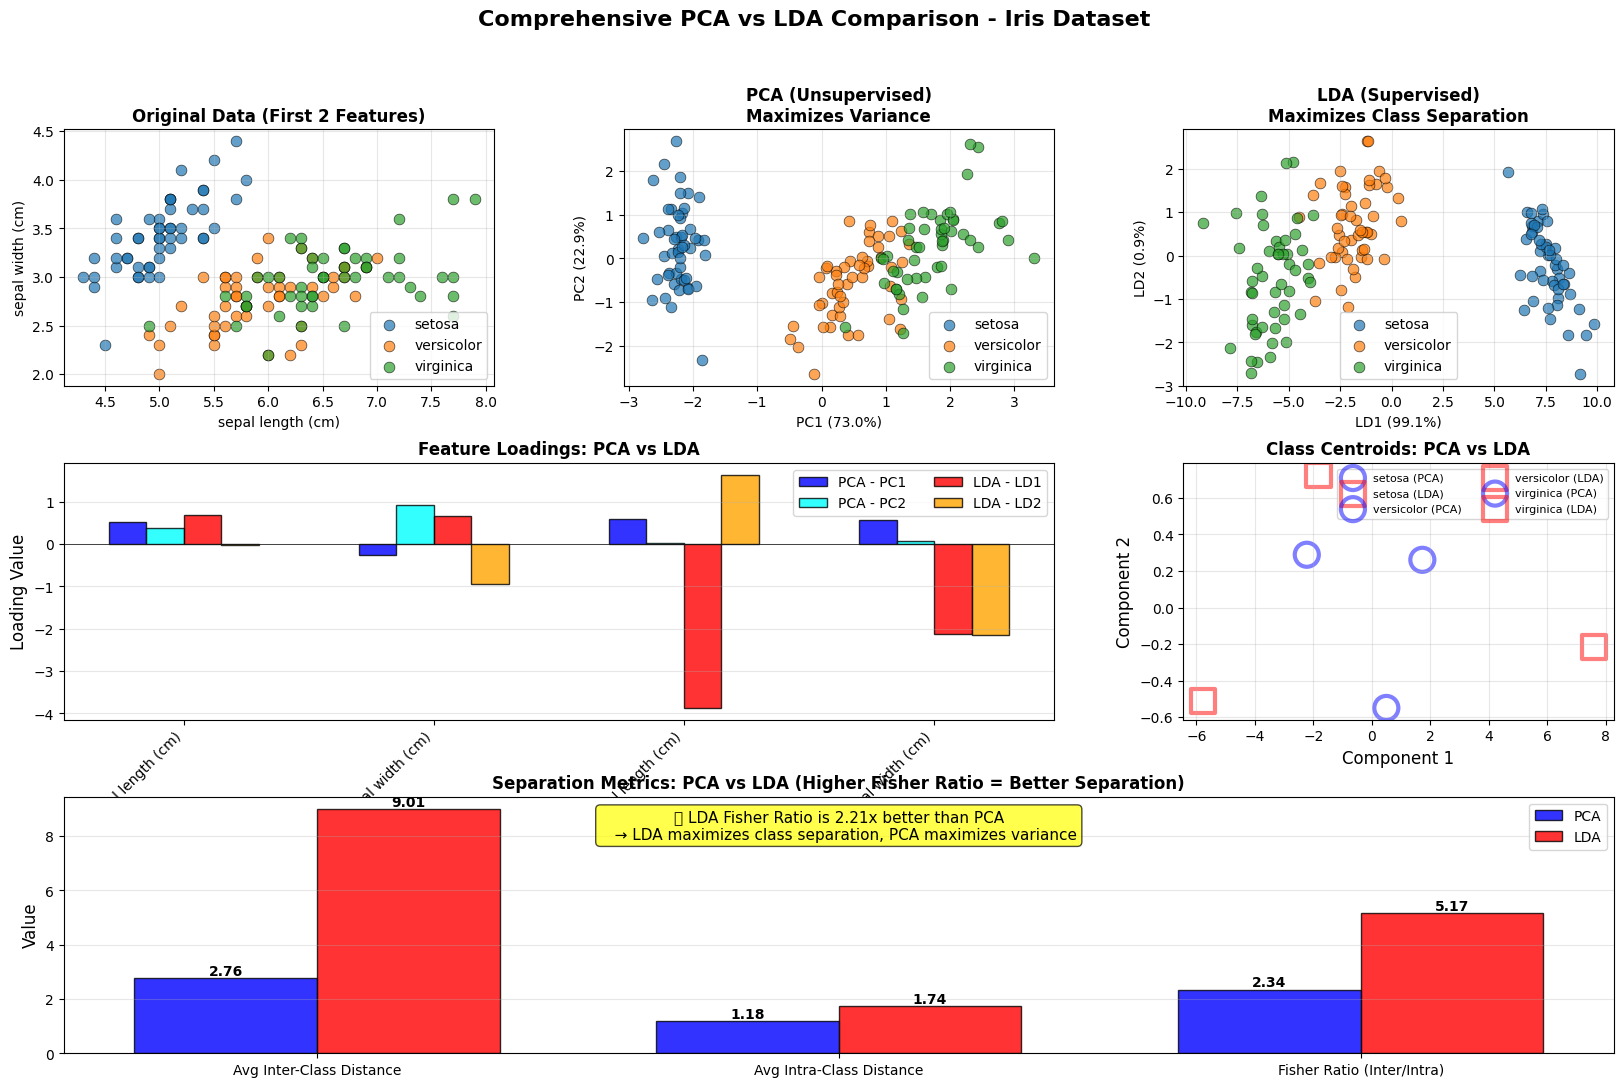

In [3]:
print("\n" + "="*100)
print("PART 3: DETAILED COMPARISON - IRIS DATASET (3 Classes)")
print("="*100)

# Load Iris
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
feature_names_iris = iris.feature_names
target_names_iris = iris.target_names

print(f"\n📊 Iris Dataset:")
print(f"   • Samples: {X_iris.shape[0]}")
print(f"   • Features: {X_iris.shape[1]}")
print(f"   • Classes: {len(target_names_iris)} ({', '.join(target_names_iris)})")

# Standardize
scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)

# Apply PCA
print(f"\n🔵 Applying PCA...")
pca_iris = PCA(n_components=2)
X_iris_pca = pca_iris.fit_transform(X_iris_scaled)
print(f"   • PCA Components: {pca_iris.n_components_}")
print(f"   • Variance explained: {pca_iris.explained_variance_ratio_}")
print(f"   • Total variance: {pca_iris.explained_variance_ratio_.sum():.3f}")

# Apply LDA
print(f"\n🔴 Applying LDA...")
lda_iris = LDA(n_components=2)
X_iris_lda = lda_iris.fit_transform(X_iris_scaled, y_iris)
print(f"   • LDA Components: {lda_iris.n_components}")
print(f"   • Variance explained: {lda_iris.explained_variance_ratio_}")
print(f"   • Total variance: {lda_iris.explained_variance_ratio_.sum():.3f}")

# Manual LDA for verification
print(f"\n🟡 Verifying with Manual LDA...")
manual_lda_iris = ManualLDA(n_components=2)
X_iris_lda_manual = manual_lda_iris.fit_transform(X_iris_scaled, y_iris)

# Visualize comparison
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Original data (2D projection)
ax1 = fig.add_subplot(gs[0, 0])
for i, target_name in enumerate(target_names_iris):
    ax1.scatter(X_iris[y_iris == i, 0], X_iris[y_iris == i, 1],
                label=target_name, alpha=0.7, s=60, edgecolors='black', linewidth=0.5)
ax1.set_xlabel(feature_names_iris[0])
ax1.set_ylabel(feature_names_iris[1])
ax1.set_title('Original Data (First 2 Features)', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# PCA projection
ax2 = fig.add_subplot(gs[0, 1])
for i, target_name in enumerate(target_names_iris):
    ax2.scatter(X_iris_pca[y_iris == i, 0], X_iris_pca[y_iris == i, 1],
                label=target_name, alpha=0.7, s=60, edgecolors='black', linewidth=0.5)
ax2.set_xlabel(f'PC1 ({pca_iris.explained_variance_ratio_[0]:.1%})')
ax2.set_ylabel(f'PC2 ({pca_iris.explained_variance_ratio_[1]:.1%})')
ax2.set_title('PCA (Unsupervised)\nMaximizes Variance', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# LDA projection
ax3 = fig.add_subplot(gs[0, 2])
for i, target_name in enumerate(target_names_iris):
    ax3.scatter(X_iris_lda[y_iris == i, 0], X_iris_lda[y_iris == i, 1],
                label=target_name, alpha=0.7, s=60, edgecolors='black', linewidth=0.5)
ax3.set_xlabel(f'LD1 ({lda_iris.explained_variance_ratio_[0]:.1%})')
ax3.set_ylabel(f'LD2 ({lda_iris.explained_variance_ratio_[1]:.1%})')
ax3.set_title('LDA (Supervised)\nMaximizes Class Separation', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Component loadings comparison
ax4 = fig.add_subplot(gs[1, :2])
pca_loadings = pd.DataFrame(
    pca_iris.components_.T,
    columns=['PC1', 'PC2'],
    index=feature_names_iris
)
lda_loadings = pd.DataFrame(
    lda_iris.scalings_[:, :2],
    columns=['LD1', 'LD2'],
    index=feature_names_iris
)

x = np.arange(len(feature_names_iris))
width = 0.15

for i, col in enumerate(['PC1', 'PC2', 'LD1', 'LD2']):
    if col in pca_loadings.columns:
        values = pca_loadings[col].values
        color = 'blue' if col == 'PC1' else 'cyan'
        label_prefix = 'PCA'
    else:
        values = lda_loadings[col].values
        color = 'red' if col == 'LD1' else 'orange'
        label_prefix = 'LDA'

    ax4.bar(x + i*width - 1.5*width, values, width,
            label=f'{label_prefix} - {col}', alpha=0.8, color=color, edgecolor='black')

ax4.set_xlabel('Features', fontsize=12)
ax4.set_ylabel('Loading Value', fontsize=12)
ax4.set_title('Feature Loadings: PCA vs LDA', fontsize=12, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(feature_names_iris, rotation=45, ha='right')
ax4.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax4.legend(ncol=2)
ax4.grid(True, alpha=0.3, axis='y')

# Class centroids
ax5 = fig.add_subplot(gs[1, 2])
for i, target_name in enumerate(target_names_iris):
    # PCA centroids
    pca_centroid = X_iris_pca[y_iris == i].mean(axis=0)
    ax5.scatter(pca_centroid[0], pca_centroid[1], marker='o', s=300,
                alpha=0.5, edgecolors='blue', linewidth=3, facecolors='none',
                label=f'{target_name} (PCA)')

    # LDA centroids
    lda_centroid = X_iris_lda[y_iris == i].mean(axis=0)
    ax5.scatter(lda_centroid[0], lda_centroid[1], marker='s', s=300,
                alpha=0.5, edgecolors='red', linewidth=3, facecolors='none',
                label=f'{target_name} (LDA)')

ax5.set_xlabel('Component 1', fontsize=12)
ax5.set_ylabel('Component 2', fontsize=12)
ax5.set_title('Class Centroids: PCA vs LDA', fontsize=12, fontweight='bold')
ax5.legend(fontsize=8, ncol=2)
ax5.grid(True, alpha=0.3)

# Separation metrics
ax6 = fig.add_subplot(gs[2, :])

# Calculate inter-class distances
from scipy.spatial.distance import pdist, squareform

def calculate_separation_metrics(X_transformed, y):
    """Calculate various separation metrics"""
    classes = np.unique(y)
    centroids = []

    for c in classes:
        centroids.append(X_transformed[y == c].mean(axis=0))

    centroids = np.array(centroids)

    # Inter-class distances (between centroids)
    inter_dist = pdist(centroids, metric='euclidean')
    avg_inter_dist = inter_dist.mean()

    # Intra-class distances (within each class)
    intra_dists = []
    for c in classes:
        X_c = X_transformed[y == c]
        if len(X_c) > 1:
            intra_dist = pdist(X_c, metric='euclidean').mean()
            intra_dists.append(intra_dist)

    avg_intra_dist = np.mean(intra_dists)

    # Fisher ratio (inter / intra)
    fisher_ratio = avg_inter_dist / avg_intra_dist if avg_intra_dist > 0 else 0

    return {
        'avg_inter_dist': avg_inter_dist,
        'avg_intra_dist': avg_intra_dist,
        'fisher_ratio': fisher_ratio
    }

pca_metrics = calculate_separation_metrics(X_iris_pca, y_iris)
lda_metrics = calculate_separation_metrics(X_iris_lda, y_iris)

metrics_comparison = pd.DataFrame({
    'PCA': [pca_metrics['avg_inter_dist'],
            pca_metrics['avg_intra_dist'],
            pca_metrics['fisher_ratio']],
    'LDA': [lda_metrics['avg_inter_dist'],
            lda_metrics['avg_intra_dist'],
            lda_metrics['fisher_ratio']]
}, index=['Avg Inter-Class Distance', 'Avg Intra-Class Distance', 'Fisher Ratio (Inter/Intra)'])

x_pos = np.arange(len(metrics_comparison.index))
width = 0.35

bars1 = ax6.bar(x_pos - width/2, metrics_comparison['PCA'], width,
                label='PCA', alpha=0.8, color='blue', edgecolor='black')
bars2 = ax6.bar(x_pos + width/2, metrics_comparison['LDA'], width,
                label='LDA', alpha=0.8, color='red', edgecolor='black')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax6.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax6.set_ylabel('Value', fontsize=12)
ax6.set_title('Separation Metrics: PCA vs LDA (Higher Fisher Ratio = Better Separation)',
              fontsize=12, fontweight='bold')
ax6.set_xticks(x_pos)
ax6.set_xticklabels(metrics_comparison.index)
ax6.legend()
ax6.grid(True, alpha=0.3, axis='y')

# Add interpretation text
interpretation = (f"🎯 LDA Fisher Ratio is {lda_metrics['fisher_ratio']/pca_metrics['fisher_ratio']:.2f}x "
                 f"better than PCA\n   → LDA maximizes class separation, PCA maximizes variance")
ax6.text(0.5, 0.95, interpretation, transform=ax6.transAxes,
         fontsize=11, ha='center', va='top',
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

plt.suptitle('Comprehensive PCA vs LDA Comparison - Iris Dataset',
             fontsize=16, fontweight='bold')
plt.savefig('01_iris_pca_lda_comparison.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: 01_iris_pca_lda_comparison.png")


PART 4: CLASSIFICATION PERFORMANCE COMPARISON

📊 Testing classifiers on different feature sets:
   • Random Forest        on Original (4D): 0.8889
   • SVM                  on Original (4D): 0.9111
   • KNN (k=5)            on Original (4D): 0.9111
   • Random Forest        on PCA (2D):     0.8889
   • SVM                  on PCA (2D):     0.9111
   • KNN (k=5)            on PCA (2D):     0.9111
   • Random Forest        on LDA (2D):     0.9778
   • SVM                  on LDA (2D):     0.9778
   • KNN (k=5)            on LDA (2D):     0.9556

✓ Saved: 02_classification_comparison.png


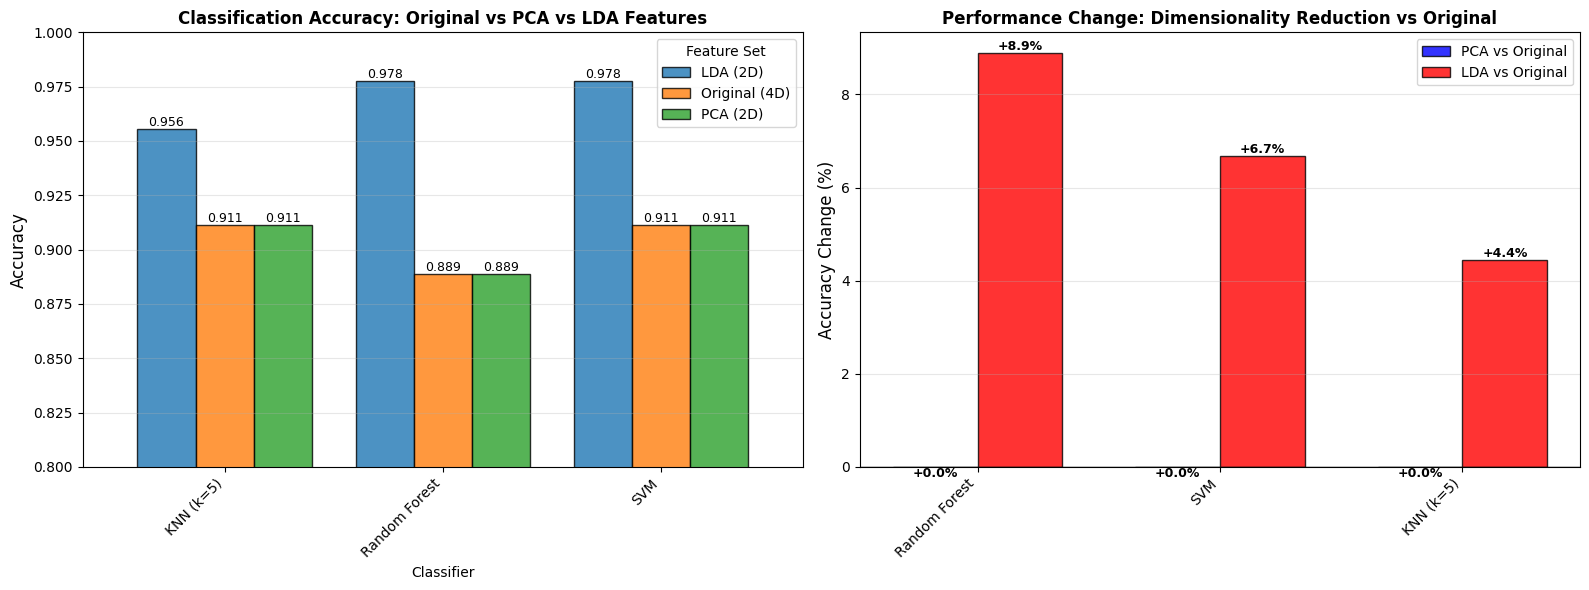

In [4]:
print("\n" + "="*100)
print("PART 4: CLASSIFICATION PERFORMANCE COMPARISON")
print("="*100)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_iris_scaled, y_iris, test_size=0.3, random_state=42, stratify=y_iris
)

# Test different scenarios
classifiers = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5)
}

results = []

print(f"\n📊 Testing classifiers on different feature sets:")

# 1. Original features
for clf_name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append({
        'Classifier': clf_name,
        'Feature Set': 'Original (4D)',
        'Accuracy': acc
    })
    print(f"   • {clf_name:<20} on Original (4D): {acc:.4f}")

# 2. PCA features (2D)
pca_train = PCA(n_components=2)
X_train_pca = pca_train.fit_transform(X_train)
X_test_pca = pca_train.transform(X_test)

for clf_name, clf in classifiers.items():
    clf_pca = classifiers[clf_name].__class__(**classifiers[clf_name].get_params())
    clf_pca.fit(X_train_pca, y_train)
    y_pred = clf_pca.predict(X_test_pca)
    acc = accuracy_score(y_test, y_pred)
    results.append({
        'Classifier': clf_name,
        'Feature Set': 'PCA (2D)',
        'Accuracy': acc
    })
    print(f"   • {clf_name:<20} on PCA (2D):     {acc:.4f}")

# 3. LDA features (2D)
lda_train = LDA(n_components=2)
X_train_lda = lda_train.fit_transform(X_train, y_train)
X_test_lda = lda_train.transform(X_test)

for clf_name, clf in classifiers.items():
    clf_lda = classifiers[clf_name].__class__(**classifiers[clf_name].get_params())
    clf_lda.fit(X_train_lda, y_train)
    y_pred = clf_lda.predict(X_test_lda)
    acc = accuracy_score(y_test, y_pred)
    results.append({
        'Classifier': clf_name,
        'Feature Set': 'LDA (2D)',
        'Accuracy': acc
    })
    print(f"   • {clf_name:<20} on LDA (2D):     {acc:.4f}")

results_df = pd.DataFrame(results)

# Visualize classification results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grouped bar chart
ax1 = axes[0]
pivot_results = results_df.pivot(index='Classifier', columns='Feature Set', values='Accuracy')
pivot_results.plot(kind='bar', ax=ax1, alpha=0.8, edgecolor='black', width=0.8)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Classification Accuracy: Original vs PCA vs LDA Features',
              fontsize=12, fontweight='bold')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.legend(title='Feature Set', fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim([0.8, 1.0])

# Add value labels
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.3f', fontsize=9)

# Improvement analysis
ax2 = axes[1]
improvement_data = []
for clf in results_df['Classifier'].unique():
    original_acc = results_df[(results_df['Classifier'] == clf) &
                              (results_df['Feature Set'] == 'Original (4D)')]['Accuracy'].values[0]
    pca_acc = results_df[(results_df['Classifier'] == clf) &
                         (results_df['Feature Set'] == 'PCA (2D)')]['Accuracy'].values[0]
    lda_acc = results_df[(results_df['Classifier'] == clf) &
                         (results_df['Feature Set'] == 'LDA (2D)')]['Accuracy'].values[0]

    improvement_data.append({
        'Classifier': clf,
        'PCA vs Original': (pca_acc - original_acc) * 100,
        'LDA vs Original': (lda_acc - original_acc) * 100
    })

improvement_df = pd.DataFrame(improvement_data)
x_pos = np.arange(len(improvement_df))
width = 0.35

bars1 = ax2.bar(x_pos - width/2, improvement_df['PCA vs Original'], width,
                label='PCA vs Original', alpha=0.8, color='blue', edgecolor='black')
bars2 = ax2.bar(x_pos + width/2, improvement_df['LDA vs Original'], width,
                label='LDA vs Original', alpha=0.8, color='red', edgecolor='black')

ax2.set_ylabel('Accuracy Change (%)', fontsize=12)
ax2.set_title('Performance Change: Dimensionality Reduction vs Original',
              fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(improvement_df['Classifier'], rotation=45, ha='right')
ax2.axhline(y=0, color='black', linewidth=1)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:+.1f}%',
                ha='center', va='bottom' if height > 0 else 'top',
                fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('02_classification_comparison.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: 02_classification_comparison.png")


PART 4: WINE DATASET (3 Classes, 13 Features)

Dataset: 178 samples, 13 features

PCA: 55.4% variance explained
LDA: 100.0% variance explained
✓ Saved: pca_lda_wine_comparison.png

PART 5: BREAST CANCER DATASET (2 Classes, 30 Features)

Dataset: 569 samples, 30 features, 2 classes
LDA max components: n_classes - 1 = 1

PCA variance by component:
  PC1: 0.443
  PC2: 0.190
  PC3: 0.094
  PC4: 0.066
  PC5: 0.055

LDA variance: 1.000
✓ Saved: pca_lda_cancer_comparison.png


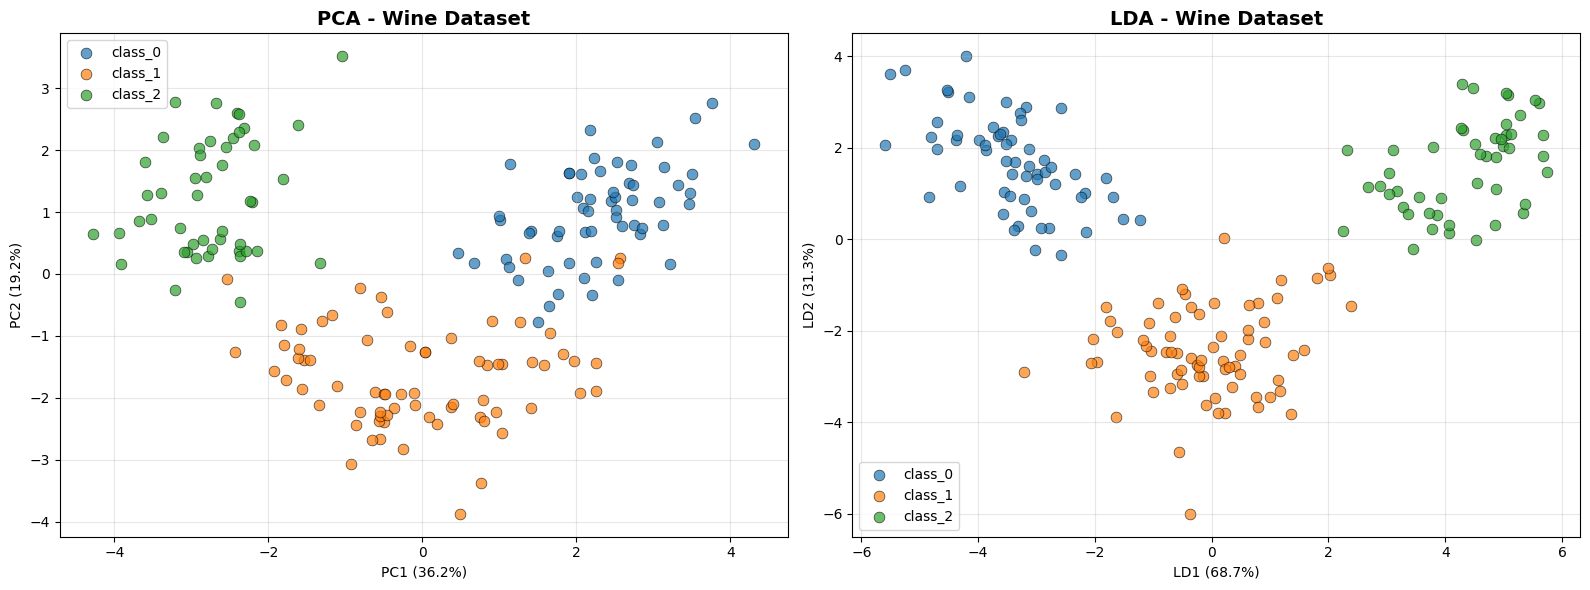

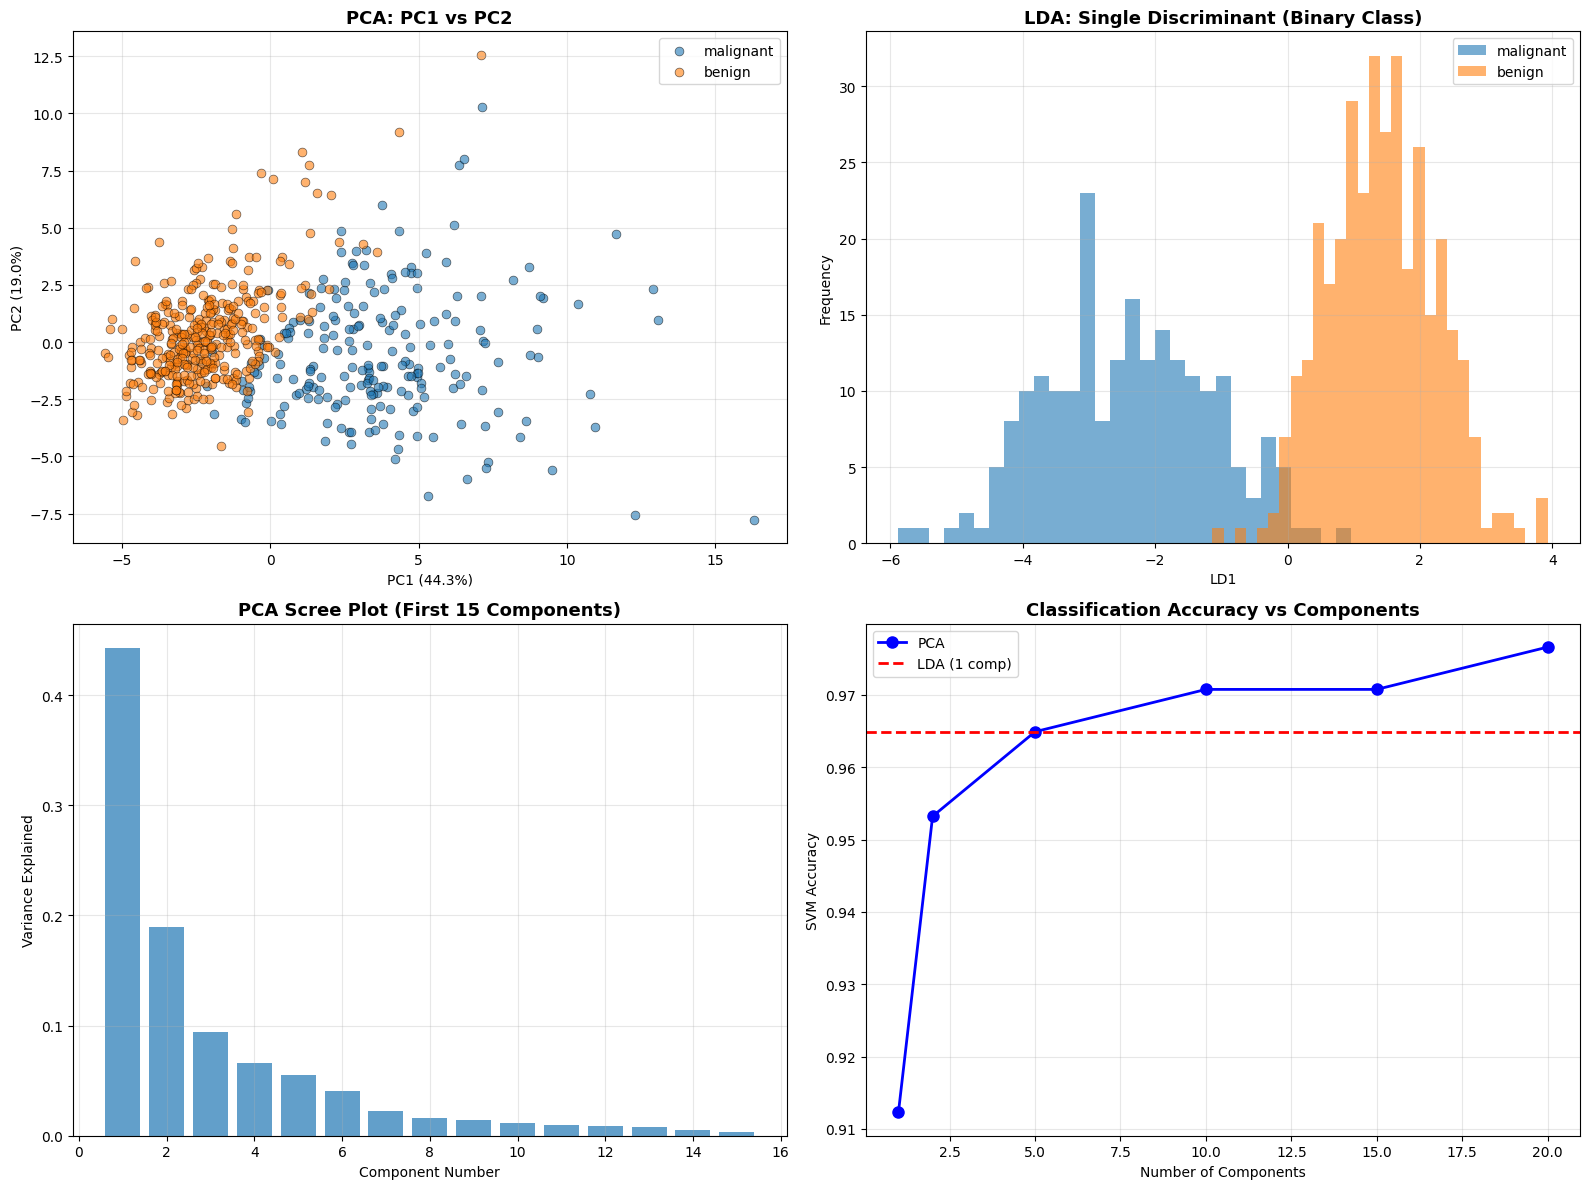

In [5]:
# ============================================================================
# PART 4: WINE DATASET (Multi-class)
# ============================================================================
print("\n" + "="*100)
print("PART 4: WINE DATASET (3 Classes, 13 Features)")
print("="*100)

wine = load_wine()
X_wine = wine.data
y_wine = wine.target

print(f"\nDataset: {X_wine.shape[0]} samples, {X_wine.shape[1]} features")

X_wine_scaled = StandardScaler().fit_transform(X_wine)

# PCA and LDA
pca_wine = PCA(n_components=2)
X_wine_pca = pca_wine.fit_transform(X_wine_scaled)

lda_wine = LDA(n_components=2)
X_wine_lda = lda_wine.fit_transform(X_wine_scaled, y_wine)

print(f"\nPCA: {pca_wine.explained_variance_ratio_.sum():.1%} variance explained")
print(f"LDA: {lda_wine.explained_variance_ratio_.sum():.1%} variance explained")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA plot
for i, name in enumerate(wine.target_names):
    axes[0].scatter(X_wine_pca[y_wine == i, 0], X_wine_pca[y_wine == i, 1],
                   label=name, alpha=0.7, s=60, edgecolors='black', linewidth=0.5)
axes[0].set_xlabel(f'PC1 ({pca_wine.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca_wine.explained_variance_ratio_[1]:.1%})')
axes[0].set_title('PCA - Wine Dataset', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# LDA plot
for i, name in enumerate(wine.target_names):
    axes[1].scatter(X_wine_lda[y_wine == i, 0], X_wine_lda[y_wine == i, 1],
                   label=name, alpha=0.7, s=60, edgecolors='black', linewidth=0.5)
axes[1].set_xlabel(f'LD1 ({lda_wine.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'LD2 ({lda_wine.explained_variance_ratio_[1]:.1%})')
axes[1].set_title('LDA - Wine Dataset', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pca_lda_wine_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: pca_lda_wine_comparison.png")

# ============================================================================
# PART 5: BREAST CANCER (Binary Classification)
# ============================================================================
print("\n" + "="*100)
print("PART 5: BREAST CANCER DATASET (2 Classes, 30 Features)")
print("="*100)

cancer = load_breast_cancer()
X_cancer = cancer.data
y_cancer = cancer.target

print(f"\nDataset: {X_cancer.shape[0]} samples, {X_cancer.shape[1]} features, 2 classes")
print(f"LDA max components: n_classes - 1 = {len(np.unique(y_cancer)) - 1}")

X_cancer_scaled = StandardScaler().fit_transform(X_cancer)

# PCA with multiple components
pca_cancer = PCA()
X_cancer_pca_full = pca_cancer.fit_transform(X_cancer_scaled)

# LDA (only 1 component for binary)
lda_cancer = LDA(n_components=1)
X_cancer_lda = lda_cancer.fit_transform(X_cancer_scaled, y_cancer)

print(f"\nPCA variance by component:")
for i in range(min(5, len(pca_cancer.explained_variance_ratio_))):
    print(f"  PC{i+1}: {pca_cancer.explained_variance_ratio_[i]:.3f}")

print(f"\nLDA variance: {lda_cancer.explained_variance_ratio_[0]:.3f}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# PCA: PC1 vs PC2
for label, name in enumerate(cancer.target_names):
    axes[0, 0].scatter(X_cancer_pca_full[y_cancer == label, 0],
                      X_cancer_pca_full[y_cancer == label, 1],
                      label=name, alpha=0.6, s=40, edgecolors='black', linewidth=0.5)
axes[0, 0].set_xlabel(f'PC1 ({pca_cancer.explained_variance_ratio_[0]:.1%})')
axes[0, 0].set_ylabel(f'PC2 ({pca_cancer.explained_variance_ratio_[1]:.1%})')
axes[0, 0].set_title('PCA: PC1 vs PC2', fontsize=13, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# LDA: 1D projection
for label, name in enumerate(cancer.target_names):
    axes[0, 1].hist(X_cancer_lda[y_cancer == label], bins=30, alpha=0.6, label=name)
axes[0, 1].set_xlabel('LD1')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('LDA: Single Discriminant (Binary Class)', fontsize=13, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Scree plot
axes[1, 0].bar(range(1, 16), pca_cancer.explained_variance_ratio_[:15], alpha=0.7)
axes[1, 0].set_xlabel('Component Number')
axes[1, 0].set_ylabel('Variance Explained')
axes[1, 0].set_title('PCA Scree Plot (First 15 Components)', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Classification comparison
X_train, X_test, y_train, y_test = train_test_split(
    X_cancer_scaled, y_cancer, test_size=0.3, random_state=42, stratify=y_cancer
)

n_components_list = [1, 2, 5, 10, 15, 20]
pca_scores = []
lda_scores = []

for n in n_components_list:
    # PCA
    pca_temp = PCA(n_components=n)
    X_train_pca = pca_temp.fit_transform(X_train)
    X_test_pca = pca_temp.transform(X_test)
    clf_pca = SVC(kernel='rbf', random_state=42)
    clf_pca.fit(X_train_pca, y_train)
    pca_scores.append(accuracy_score(y_test, clf_pca.predict(X_test_pca)))

    # LDA (max 1 component for binary)
    if n == 1:
        lda_temp = LDA(n_components=1)
        X_train_lda = lda_temp.fit_transform(X_train, y_train)
        X_test_lda = lda_temp.transform(X_test)
        clf_lda = SVC(kernel='rbf', random_state=42)
        clf_lda.fit(X_train_lda, y_train)
        lda_score = accuracy_score(y_test, clf_lda.predict(X_test_lda))
        lda_scores = [lda_score] * len(n_components_list)

axes[1, 1].plot(n_components_list, pca_scores, 'o-', linewidth=2,
               markersize=8, label='PCA', color='blue')
axes[1, 1].axhline(lda_scores[0], linestyle='--', linewidth=2,
                  label=f'LDA (1 comp)', color='red')
axes[1, 1].set_xlabel('Number of Components')
axes[1, 1].set_ylabel('SVM Accuracy')
axes[1, 1].set_title('Classification Accuracy vs Components', fontsize=13, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pca_lda_cancer_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: pca_lda_cancer_comparison.png")
